<a href="https://colab.research.google.com/github/isabela2206/lia1_2026_2/blob/main/Aula_09_Adaptado_Fashion_MNIST_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Imagens com Rede Neural Convolucional — Fashion-MNIST

**Autora:** Isabela &nbsp;·&nbsp; **Disciplina:** Laboratório de Inovação e Automação &nbsp;·&nbsp; **Data:** 14/09/2026

---

**Objetivo.** Construir, treinar e avaliar uma rede neural convolucional capaz de classificar imagens de vestuário em 10 categorias, percorrendo o pipeline completo de um projeto de IA:

`Dados → Pré-processamento → Modelo → Treinamento → Validação → Teste → Inferência`

**Dataset.** Fashion-MNIST: 70.000 imagens em escala de cinza de 28×28 pixels (60.000 de treino e 10.000 de teste), distribuídas uniformemente entre 10 classes de peças de roupa.

**Ambiente.** Google Colab · Python 3 · TensorFlow 2.x · CPU (GPU opcional, não necessária)

**Tempo estimado de execução:** cerca de 3 minutos com o notebook completo.

**Como executar:** `Ambiente de execução → Executar tudo`. A Seção 8 é a única que exige uma ação manual: o upload de uma imagem própria para `/content/`.

> ℹ️ Este notebook adapta o pipeline originalmente desenvolvido para o CIFAR-10. As linhas de código alteradas em relação àquela versão estão marcadas com o comentário `# MUDOU`, e a Seção 9 consolida todas as diferenças. A intenção é evidenciar que **o valor está no pipeline, não no dataset**.

## 1. Bibliotecas e carregamento dos dados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


**Saída esperada:** a versão do TensorFlow instalada no Colab (2.x). Mensagens de aviso sobre CUDA ou TensorRT são normais ao executar na CPU e podem ser ignoradas.

In [2]:
# MUDOU: trocar o dataset do Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Treino:", x_train.shape)
print("Teste :", x_test.shape)
print("Rótulos treino:", y_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino: (60000, 28, 28)
Teste : (10000, 28, 28)
Rótulos treino: (60000,)


**Saída esperada:** `(60000, 28, 28)`, `(10000, 28, 28)` e `(60000,)`.

Duas diferenças estruturais em relação ao CIFAR-10 merecem atenção, porque são a origem da maior parte dos erros ao adaptar o pipeline:

| Aspecto | CIFAR-10 | Fashion-MNIST | Consequência |
|---|---|---|---|
| Formato das imagens | `(50000, 32, 32, 3)` | `(60000, 28, 28)` | falta o eixo de canais; será criado na Seção 3 |
| Formato dos rótulos | `(50000, 1)` | `(60000,)` | `y_train[i][0]` passa a ser `y_train[i]` |

O eixo de canais está ausente porque as imagens são em escala de cinza: há um único valor de intensidade por pixel, em vez dos três valores RGB do CIFAR-10.

In [3]:
# MUDOU: classes de vestuário no lugar de animais e veículos
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Verificação do balanceamento das classes
valores, contagens = np.unique(y_train, return_counts=True)

for valor, contagem in zip(valores, contagens):
    print(f"{valor} - {class_names[valor]:12s}: {contagem}")

0 - T-shirt/top : 6000
1 - Trouser     : 6000
2 - Pullover    : 6000
3 - Dress       : 6000
4 - Coat        : 6000
5 - Sandal      : 6000
6 - Shirt       : 6000
7 - Sneaker     : 6000
8 - Bag         : 6000
9 - Ankle boot  : 6000


**Saída esperada:** 6.000 imagens para cada uma das 10 classes.

O dataset é perfeitamente balanceado, o que justifica o uso da **acurácia** como métrica principal. Em datasets desbalanceados essa métrica seria enganosa: um modelo que sempre prevê a classe majoritária poderia atingir acurácia alta sem aprender nada.

## 2. Visualização dos dados

Antes de qualquer modelagem, é necessário inspecionar visualmente os dados. Essa etapa revela a natureza do problema e antecipa as dificuldades que o modelo enfrentará.

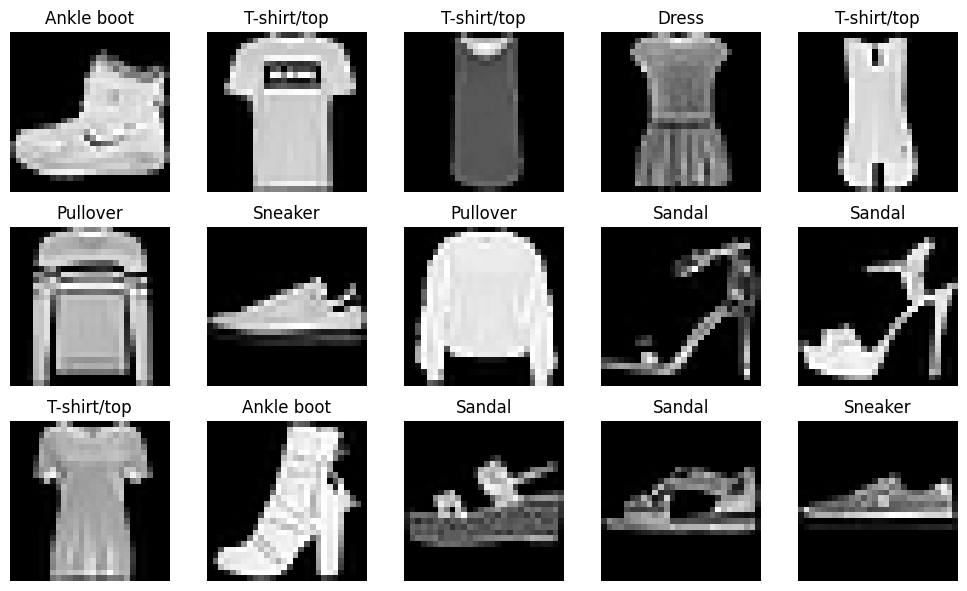

In [4]:
plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")   # MUDOU: cmap="gray" para imagem sem canal de cor
    plt.title(class_names[y_train[i]])    # MUDOU: y_train[i] no lugar de y_train[i][0]
    plt.axis("off")

plt.tight_layout()
plt.show()

**Figura 1 — Amostra de 15 imagens do conjunto de treino com seus rótulos.**

Três características ficam evidentes e determinam o desempenho do modelo:

- **Padronização.** Todas as peças aparecem centralizadas, em escala semelhante e sobre fundo preto uniforme. Não há variação de pose, iluminação ou contexto.
- **Ausência de cor.** A cor, que no CIFAR-10 ajuda a distinguir um céu azul de um gramado, aqui não carrega informação alguma. Toda a discriminação depende da forma.
- **Similaridade entre classes.** Pullover, Coat e Shirt compartilham a mesma silhueta de manga comprida. Essa semelhança será confirmada quantitativamente pela matriz de confusão na Seção 6.1.

## 3. Pré-processamento

Duas transformações são necessárias antes do treinamento: a normalização dos valores dos pixels e a criação do eixo de canais.

In [5]:
print("Antes:", x_train.min(), "a", x_train.max())
print("Formato antes:", x_train.shape)

# Normalização: 0-255 -> 0-1 (igual ao CIFAR-10)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# MUDOU: a Conv2D espera 4 dimensões (amostras, altura, largura, canais).
# Como a imagem é em escala de cinza, é preciso criar o canal: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("\nDepois:", x_train.min(), "a", x_train.max())
print("Formato depois:", x_train.shape)

Antes: 0 a 255
Formato antes: (60000, 28, 28)

Depois: 0.0 a 1.0
Formato depois: (60000, 28, 28, 1)


**Saída esperada:** intervalo de `0.0` a `1.0` e formato `(60000, 28, 28, 1)`.

> ⚠️ Se o formato exibido ainda for `(60000, 28, 28)`, a célula anterior não foi executada e a Seção 4 falhará com erro de dimensão. Se o intervalo aparecer como `0.0 a 0.00392`, a célula foi executada duas vezes e a normalização foi aplicada em dobro — nesse caso, recarregue os dados a partir da Seção 1.

**Por que normalizar.** Os pesos da rede são inicializados com valores pequenos, próximos de zero. Entradas na faixa de 0 a 255 produzem ativações e gradientes de magnitude elevada, o que torna a descida do gradiente instável e lenta. Reescalar para o intervalo $[0, 1]$ coloca entradas e pesos na mesma ordem de grandeza e acelera a convergência.

**Por que criar o eixo de canais.** A camada `Conv2D` opera sobre tensores de quatro dimensões: `(amostras, altura, largura, canais)`. O CIFAR-10 já fornecia o eixo de canais com tamanho 3 (RGB); aqui ele precisa ser criado explicitamente com tamanho 1.

## 4. Construção do modelo

A arquitetura é uma CNN sequencial com dois blocos convolucionais seguidos de um classificador denso — **idêntica à utilizada no CIFAR-10**, exceto pelo formato da camada de entrada.

In [6]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(28, 28, 1)),   # MUDOU: era (32, 32, 3)
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

**Saída esperada:** tabela com 8 linhas e cerca de 121 mil parâmetros treináveis.

### 4.1 Decisões de projeto

| Decisão | Valor adotado | Justificativa |
|---|---|---|
| Normalização das entradas | divisão por 255 | coloca entradas e pesos na mesma ordem de grandeza |
| Filtros convolucionais | 32 e depois 64 | padrão piramidal: poucas características simples nas primeiras camadas, muitas características compostas nas seguintes |
| Tamanho do kernel | 3×3 | menor janela capaz de detectar orientação; padrão consolidado desde a VGG |
| Função de ativação oculta | ReLU | não satura para valores positivos, evitando o desvanecimento do gradiente |
| Pooling | MaxPooling 2×2 | reduz a dimensão pela metade e introduz invariância a pequenos deslocamentos |
| Ativação de saída | softmax | converte as saídas em distribuição de probabilidade sobre as 10 classes |
| Função de perda | `sparse_categorical_crossentropy` | apropriada para rótulos inteiros; a versão sem `sparse` exigiria codificação one-hot |
| Otimizador | Adam | taxa de aprendizado adaptativa por parâmetro, dispensando ajuste manual |
| Épocas | 5 | suficiente para convergir antes do início do sobreajuste (verificado na Seção 6) |
| Divisão de validação | 20% do treino | monitora a generalização sem consumir o conjunto de teste |

### 4.2 Redução espacial ao longo da rede

Cada convolução 3×3 sem preenchimento remove 2 pixels de cada dimensão; cada pooling 2×2 divide a dimensão por dois:

$$28 \times 28 \;\xrightarrow{\text{conv}}\; 26 \times 26 \;\xrightarrow{\text{pool}}\; 13 \times 13 \;\xrightarrow{\text{conv}}\; 11 \times 11 \;\xrightarrow{\text{pool}}\; 5 \times 5$$

O `Flatten` recebe, portanto, $5 \times 5 \times 64 = 1600$ valores. É essa diferença que explica a contagem de parâmetros menor que a do CIFAR-10 (121 mil contra 167 mil), apesar de a arquitetura ser a mesma: a imagem de entrada é menor, logo o vetor achatado também é.

### 4.3 A camada de saída

A softmax converte os valores brutos $z_i$ produzidos pela última camada densa em probabilidades:

$$P(y = i) = \frac{e^{z_i}}{\sum_{j=1}^{10} e^{z_j}}$$

As saídas resultantes são todas positivas e somam 1, o que permite interpretá-las como o grau de confiança do modelo em cada classe — valor que será exibido nas inferências das Seções 7 e 8.

## 5. Treinamento e validação

O conjunto de treino é dividido em duas partes: 48.000 imagens para o ajuste dos pesos e 12.000 para validação. O conjunto de teste permanece intocado até a Seção 6, de modo que a avaliação final não seja contaminada por decisões tomadas durante o desenvolvimento.

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.8219 - loss: 0.4929 - val_accuracy: 0.8694 - val_loss: 0.3566
Epoch 2/5
 641/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.8723 - loss: 0.3539

**Saída esperada:** 5 épocas de 1.500 lotes cada, com `accuracy` crescente e `loss` decrescente. Na CPU, cada época leva de 20 a 40 segundos. Ao final, a acurácia de validação costuma situar-se entre 88% e 91%.

> ℹ️ Pequenas variações nos valores entre execuções são esperadas: a inicialização dos pesos e o embaralhamento dos lotes são aleatórios. Para resultados reproduzíveis, seria necessário fixar a semente com `tf.random.set_seed()`.

## 6. Avaliação do modelo

In [ ]:
# Curvas de aprendizado
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Curvas de aprendizado')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Avaliação final no conjunto de teste
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"\nAcurácia no teste: {test_accuracy:.2%}")

**Figura 2 — Evolução da acurácia de treino e de validação ao longo das épocas.**

Ambas as curvas crescem de forma consistente e a distância entre elas permanece pequena, indicando que o modelo ainda **não** entrou em sobreajuste ao fim da quinta época. O sobreajuste se manifestaria como uma curva de treino que continua subindo enquanto a de validação estagna ou decresce; caso isso ocorresse, as estratégias usuais seriam interromper o treinamento mais cedo ou acrescentar regularização por `Dropout`.

A acurácia de teste, em torno de 90%, é substancialmente superior aos 67% obtidos no CIFAR-10 com a **mesma arquitetura**. A diferença não decorre da qualidade do modelo, mas da dificuldade intrínseca de cada problema: no Fashion-MNIST as peças são centralizadas, padronizadas e recortadas sobre fundo uniforme, enquanto o CIFAR-10 contém fotografias naturais com variação de pose, escala, iluminação e fundo.

### 6.1 Matriz de confusão

A acurácia sintetiza o desempenho global em um único número, mas oculta *quais* erros o modelo comete. A matriz de confusão desagrega esse resultado por classe:

- **Diagonal principal:** classificações corretas.
- **Fora da diagonal:** confusões entre classes.

In [ ]:
# Previsões para todo o conjunto de teste
y_pred = model.predict(x_test, verbose=0)

# Classe com maior probabilidade
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusão
matriz_confusao = tf.math.confusion_matrix(
    y_test.flatten(),
    y_pred_classes
)

# Exibição
plt.figure(figsize=(9, 8))

plt.imshow(matriz_confusao, cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.colorbar()

# Valores dentro da matriz
for i in range(10):
    for j in range(10):
        plt.text(
            j, i,
            matriz_confusao[i, j].numpy(),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

**Figura 3 — Matriz de confusão sobre as 10.000 imagens do conjunto de teste.**

A diagonal concentra a maior parte dos valores, como esperado de um modelo com cerca de 90% de acurácia. Os erros, porém, não se distribuem de maneira uniforme: concentram-se em um bloco específico da matriz, analisado quantitativamente a seguir.

### 6.2 Ranking das maiores confusões

Ordenar os valores fora da diagonal torna explícito o padrão de erro que a leitura visual da matriz apenas sugere.

In [ ]:
# Ranking dos maiores erros (fora da diagonal)
matriz = matriz_confusao.numpy()

erros = []

for i in range(10):
    for j in range(10):
        if i != j:
            erros.append((matriz[i, j], class_names[i], class_names[j]))

erros.sort(reverse=True)

print("Maiores confusões (Real -> Previsto):\n")

for quantidade, real, previsto in erros[:10]:
    print(f"{real:12s} -> {previsto:12s} : {quantidade}")

# Acurácia individual por classe
print("\n\nAcurácia por classe:\n")

for i in range(10):
    acertos = matriz[i, i]
    total = matriz[i].sum()
    print(f"{class_names[i]:12s}: {acertos / total:.1%}")

**Saída esperada:** as primeiras posições do ranking ocupadas por pares envolvendo a classe Shirt, e acurácia individual variando de aproximadamente 65% (Shirt) a mais de 98% (Trouser, Bag, Sandal).

### Análise dos erros

As confusões concentram-se em um único grupo: **Shirt, T-shirt/top, Pullover e Coat**. Todas as quatro são peças de tronco, com silhueta retangular e mangas, cuja distinção na vida real depende de detalhes — gola, botões, zíper, espessura do tecido, comprimento da manga — que ocupam poucos pixels e desaparecem na resolução de 28×28 em escala de cinza. A classe Shirt é a mais penalizada por ser justamente a intermediária entre as outras três: compartilha o corte da camiseta e as mangas do casaco.

Em oposição, as classes com melhor desempenho — Trouser, Bag, Sandal, Ankle boot — possuem silhuetas inconfundíveis. A calça tem duas pernas alongadas; a bolsa é um bloco com alça; os calçados ocupam a porção inferior do quadro com formato horizontal. A rede distingue essas classes com facilidade porque a **forma global** basta, e forma global é exatamente o tipo de característica que duas camadas convolucionais conseguem extrair.

Vale notar que os erros são **simétricos e semanticamente coerentes**: o modelo confunde Shirt com Coat, não com Sandal. Isso indica que a rede aprendeu uma representação significativa do domínio, e não associações arbitrárias — um sinal de aprendizado saudável, ainda que limitado pela capacidade da arquitetura.

O mesmo fenômeno foi observado no CIFAR-10, onde o par mais confundido era **cat ↔ dog**: dois quadrúpedes de silhueta semelhante em baixa resolução. A conclusão se repete entre datasets distintos: **o erro de uma CNN rasa concentra-se em classes que compartilham a forma global e diferem apenas em detalhes finos.**

## 7. Inferência com uma imagem do conjunto de teste

Avaliado o desempenho agregado, resta demonstrar o uso do modelo sobre uma única imagem — que é como ele operaria em produção.

In [ ]:
# Escolher uma imagem, alterando apenas o índice
indice = 122

imagem = x_test[indice]
classe_real = y_test[indice]        # MUDOU: sem o [0]

# Preparar para o modelo: acrescentar a dimensão de lote
imagem_modelo = np.expand_dims(imagem, axis=0)

# Fazer a previsão
previsoes = model.predict(imagem_modelo, verbose=0)

classe_prevista = np.argmax(previsoes)
confianca = np.max(previsoes)

# Mostrar resultado
plt.imshow(imagem.squeeze(), cmap="gray")   # MUDOU: squeeze() remove o canal; cmap="gray"
plt.title(
    f"Real: {class_names[classe_real]}\n"
    f"Previsto: {class_names[classe_prevista]} ({confianca:.1%})"
)
plt.axis("off")
plt.show()

# Três classes mais prováveis
print("Distribuição de probabilidade (3 maiores):\n")

for posicao in np.argsort(previsoes[0])[::-1][:3]:
    print(f"{class_names[posicao]:12s}: {previsoes[0][posicao]:.1%}")

**Figura 4 — Inferência sobre a imagem de índice 122 do conjunto de teste.**

O modelo espera sempre um **lote** de imagens, mesmo quando há apenas uma; daí o `expand_dims(axis=0)`, que transforma o formato `(28, 28, 1)` em `(1, 28, 28, 1)`.

A distribuição de probabilidade é mais informativa que a previsão isolada. Quando a confiança se aproxima de 100%, o modelo considera a classe inequívoca. Quando se reparte entre duas ou três classes, trata-se de um caso ambíguo — e as classes que dividem a probabilidade costumam ser precisamente as identificadas como confusas na Seção 6.2. Basta alterar o índice para observar esse comportamento em diferentes exemplos.

## 8. Inferência com uma imagem externa

A prova real do modelo é sua aplicação a uma imagem que não pertence ao dataset.

> ⚠️ **Esta seção exige ação manual.** Faça o upload de uma fotografia de peça de roupa para `/content/` (ícone de pasta na barra lateral esquerda) com o nome `roupa.jpg`, ou ajuste o caminho na célula abaixo. Sem isso a célula falhará com `FileNotFoundError`.

Para obter um resultado razoável, a imagem deve aproximar-se das condições do dataset: peça isolada e centralizada, fundo liso, sem pessoa vestindo a roupa.

In [ ]:
# Carregar uma nova imagem
img = tf.keras.utils.load_img(
    "/content/roupa.jpg",
    target_size=(28, 28),
    color_mode="grayscale"     # MUDOU: converter para escala de cinza
)

# Preparar a imagem
img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0

# MUDOU: o Fashion-MNIST tem fundo PRETO e objeto claro.
# Uma foto comum costuma ser o contrário, então invertemos as intensidades.
img_array = 1.0 - img_array

img_array = np.expand_dims(img_array, axis=0)

# Fazer a previsão
previsoes = model.predict(img_array, verbose=0)

classe_prevista = np.argmax(previsoes)
confianca = np.max(previsoes)

# Mostrar resultado
plt.imshow(img_array[0].squeeze(), cmap="gray")
plt.title(
    f"Previsto: {class_names[classe_prevista]} "
    f"({confianca:.1%})"
)
plt.axis("off")
plt.show()

**Figura 5 — Inferência sobre imagem externa ao dataset.**

Esta é a etapa em que o modelo tende a falhar, e a razão é instrutiva. A rede não aprendeu o conceito abstrato de "camiseta": aprendeu a reconhecer padrões de intensidade em imagens de 28×28 com fundo escuro, objeto claro, centralizado e recortado. Qualquer desvio dessas condições — fundo estampado, sombra acentuada, ângulo oblíquo, peça vestida por uma pessoa — produz uma entrada fora da distribuição de treino, e a previsão deixa de ser confiável.

A inversão de intensidades aplicada acima é um ajuste manual que evidencia o problema: o pré-processamento precisou ser adaptado por inspeção visual da imagem, o que não é viável em um sistema real. A correção adequada envolveria segmentação do objeto, recorte automático e normalização de contraste — ou, preferencialmente, treinar com imagens representativas do domínio de aplicação desde o início.

Se a confiança exibida for alta mas a classe estiver errada, vale lembrar que a softmax **sempre** produz uma distribuição que soma 1: o modelo é obrigado a escolher uma das 10 classes, ainda que a imagem não pertença a nenhuma delas. Confiança alta não equivale a acerto.

## 9. Síntese: o que muda ao trocar de dataset

| Ponto do pipeline | CIFAR-10 | Fashion-MNIST |
|---|---|---|
| Carregamento | `cifar10.load_data()` | `fashion_mnist.load_data()` |
| Formato das imagens | `(50000, 32, 32, 3)` | `(60000, 28, 28)` |
| Formato dos rótulos | `(50000, 1)` → `y[i][0]` | `(60000,)` → `y[i]` |
| Eixo de canais | já presente (RGB) | criado com `expand_dims(..., axis=-1)` |
| Camada `Input` | `(32, 32, 3)` | `(28, 28, 1)` |
| Exibição com `imshow` | direta | `.squeeze()` e `cmap="gray"` |
| `class_names` | animais e veículos | peças de vestuário |
| Acurácia de teste obtida | ≈ 67% | ≈ 90% |

Todo o restante — normalização, arquitetura, `compile`, `fit`, curvas de aprendizado, matriz de confusão e rotina de inferência — permanece inalterado. Essa é a conclusão central do exercício: **o pipeline é o ativo reaproveitável; o dataset é apenas um caso de aplicação.**

### Adaptação para outros datasets

**MNIST (dígitos manuscritos de 0 a 9).** Substituir `fashion_mnist` por `mnist` e definir `class_names = [str(i) for i in range(10)]`. Nenhuma outra alteração é necessária, pois o formato dos dados é idêntico. A acurácia esperada ultrapassa 98%, já que os dígitos possuem traços topologicamente distintos.

**CIFAR-100 (100 classes).** Usar `cifar100.load_data()`. A camada de saída passa a `Dense(100, activation='softmax')` e os laços `range(10)` da matriz de confusão precisam acompanhar o novo número de classes — recomenda-se, nesse caso, omitir os valores numéricos escritos dentro da matriz, sob pena de ilegibilidade. A acurácia cai consideravelmente com esta arquitetura, pois há 100 classes e apenas 500 imagens de treino por classe.

## 10. Limitações e próximos passos

**Limitações do trabalho**

1. **Capacidade da arquitetura.** Duas camadas convolucionais extraem bordas e texturas simples, insuficientes para discriminar detalhes finos como gola ou botões. O desempenho satura em torno de 90% independentemente do número de épocas.
2. **Ausência de regularização.** Não foram empregados `Dropout` nem `BatchNormalization`. Com mais épocas, o sobreajuste se manifestaria.
3. **Ausência de aumento de dados.** Rotações, deslocamentos e espelhamentos horizontais ampliariam a variabilidade do treino e melhorariam a generalização, especialmente para imagens externas.
4. **Métrica única.** A acurácia é adequada neste dataset por ele ser balanceado, mas precisão, revocação e F1 por classe descreveriam melhor o desempenho sobre as classes confundidas.
5. **Validação não reproduzível.** Sem fixação de semente aleatória, os resultados variam entre execuções, o que impede a comparação rigorosa entre configurações.
6. **Pré-processamento manual na inferência externa.** A inversão de intensidades da Seção 8 foi definida por inspeção visual e não constitui solução generalizável.

**Próximos passos sugeridos**

- Acrescentar `BatchNormalization` após cada convolução e `Dropout(0.3)` antes da camada densa final, o que costuma elevar a acurácia à faixa de 93% a 94% neste dataset.
- Incluir um terceiro bloco convolucional com 128 filtros.
- Aplicar aumento de dados com `tf.keras.layers.RandomFlip` e `RandomRotation`.
- Substituir o `validation_split` fixo por validação cruzada k-fold.
- Fixar `tf.random.set_seed(42)` e comparar configurações de forma controlada.
- Avaliar transferência de aprendizado a partir de uma rede pré-treinada, ainda que a baixa resolução limite o ganho esperado.

## 11. Referências

XIAO, H.; RASUL, K.; VOLLGRAF, R. **Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms.** arXiv:1708.07747, 2017. Disponível em: https://arxiv.org/abs/1708.07747

ZALANDO RESEARCH. **Fashion-MNIST dataset.** Repositório oficial. Disponível em: https://github.com/zalandoresearch/fashion-mnist

KERAS. **Datasets API — fashion_mnist.** Documentação oficial. Disponível em: https://keras.io/api/datasets/fashion_mnist/

KRIZHEVSKY, A. **Learning multiple layers of features from tiny images.** Technical Report, University of Toronto, 2009. (dataset CIFAR-10, utilizado na versão original deste pipeline)

---

*Notebook desenvolvido como adaptação do pipeline apresentado na Aula 09.*